## 1. Imports and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:

tickers = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}

all_tickers = [ticker for sector in tickers.values() for ticker in sector]



In [3]:
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(
    [ticker for sector in tickers.values() for ticker in sector],
    start=start_date,
    end=end_date,
    interval = "1mo"
)["Close"]

# Compute returns
returns = np.log(data).diff().dropna()

# Data Quality Checks
# 1. Are there any NaNs?
print(returns.isna().sum().sum())

# 2. Are they at the start?
print(returns.iloc[0].isna().sum())

# 3. Flag outliers (returns > 50% or < -50%)
outliers = (returns > 0.5) | (returns < -0.5)
outliers_df = returns[outliers].stack(level = 'Ticker')
print(outliers_df)

data.to_csv("data/prices.csv")
returns.to_csv("data/returns.csv")

C:\Users\godwi\AppData\Local\Temp\ipykernel_27548\1760627635.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  60 of 60 completed

0
0
Date        Ticker
2013-05-01  TSLA      0.593717
2016-02-01  FCX       0.506032
2020-03-01  EOG      -0.565959
            SLB      -0.697216
            SPG      -0.808050
2020-08-01  TSLA      0.554719
2022-04-01  NFLX     -0.676915
dtype: float64


In [4]:
# Compare to benchmark
spy_row = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval = "1mo"
)

spy_prices = spy_row["Close"]["SPY"]

spy_returns = np.log(spy_prices).diff().dropna()
spy_returns = spy_returns.reindex(returns.index)
spy_returns.to_csv("data/spy_returns.csv")

# Check shape
print(returns.shape)        # (T, N)
print(spy_returns.shape)    # (T,)
# Confirm all share the same index
assert returns.index.equals(spy_returns.index)

assert len(returns) == len(spy_returns), \
    "returns and spy_returns have different lengths"


C:\Users\godwi\AppData\Local\Temp\ipykernel_27548\2373587483.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_row = yf.download(
[*********************100%***********************]  1 of 1 completed

(143, 60)
(143,)


## 2. Raw Signals

In [5]:
# Pull Fundamental Data
# Market Cap
shares_dict = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_dict[ticker] = shares
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        shares_dict[ticker] = None

shares_series = pd.Series(shares_dict)
missing = shares_series[shares_series.isna()]
print(missing) # None
market_cap = data.multiply(shares_series, axis=1)
market_cap.to_csv("data/market_cap.csv")
log_market_cap = np.log(market_cap)
log_market_cap.to_csv("data/log_market_cap.csv")

print(log_market_cap.shape) # 120 Months x 60 stocks
print(log_market_cap.head())

Series([], dtype: int64)
(180, 60)
                 AAPL  ABBV        AEP        AMT       AMZN        APD  \
Date                                                                      
2010-01-01  25.159348   NaN  23.028371  23.375253  24.934689  23.058531   
2010-02-01  25.222695   NaN  23.010457  23.380188  24.877169  22.956325   
2010-03-01  25.361125   NaN  23.026977  23.379015  25.014063  23.038330   
2010-04-01  25.466405   NaN  23.030481  23.335853  25.023811  23.075885   
2010-05-01  25.450149   NaN  22.972487  23.328968  24.935087  22.969917   

                 AVGO        BAC        BLK        CAT  ...        SLB  \
Date                                                    ...              
2010-01-01  22.481703  25.137923  23.802871  23.507535  ...  24.887843   
2010-02-01  22.525053  25.230955  23.825895  23.595615  ...  24.853193   
2010-03-01  22.649731  25.300556  23.825769  23.692438  ...  24.891091   
2010-04-01  22.647295  25.299434  23.657311  23.778736  ...  25.00925

In [6]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
# Compute Raw Signal Values
# 1. Market Beta
# Run OLS over past 36 months
beta_window = 36
monthly_index = returns.index
beta_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

assert returns.index.equals(spy_returns.index), \
    "returns and spy_returns have different indices — align them first"

for i, date in enumerate(monthly_index):
    if i < beta_window:
        continue  # Not enough data for the first few months


    window_returns = returns.iloc[i-beta_window:i]
    window_spy = spy_returns.iloc[i-beta_window:i]
    
    valid_mask = window_spy.notna() 
    if valid_mask.sum() < 24:
        continue

    spy_window_clean = window_spy[valid_mask] 

    for ticker in all_tickers:
        y = window_returns.loc[window_spy.index, ticker]

        combined_valid = valid_mask & y.notna()

        if combined_valid.sum() < 24: 
            continue

        y_clean = y[combined_valid].values
        spy_clean = window_spy[combined_valid].values
        X_clean = add_constant(spy_clean, has_constant="add")  # Recreate X with cleaned spy data

        try:
            model = OLS(y_clean, X_clean).fit()
            beta_panel.loc[date, ticker] = model.params[1]  # Store the beta coefficient

        except Exception:
            pass

beta_panel.to_csv("data/signal_beta_raw.csv")


    

In [7]:
# Sanity check
print((beta_panel < -1).sum().sum())
print((beta_panel > 3).sum().sum()) 
beta_panel.describe()

0
12


,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,1.244405,1.022419,1.745588,0.999038,1.228418,1.168852,1.466792,1.365362,1.417897,1.419713,...,0.969819,0.630043,0.631749,1.233676,0.369929,0.885947,0.886431,0.236430,2.249954,1.200193
std,0.122481,0.192734,0.524234,0.234134,0.175648,0.091776,0.188988,0.136645,0.203729,0.211289,...,0.195818,0.360344,0.266760,0.640286,0.327507,0.226564,0.166189,0.256728,0.488829,0.145857
min,0.903191,0.749327,0.923619,0.298526,0.903933,0.933789,1.156358,0.993033,0.939030,1.067052,...,0.691076,-0.034936,0.150482,0.418340,-0.147800,0.372993,0.637699,-0.401133,1.422055,0.949857
25%,1.184540,0.859771,1.343460,0.917286,1.084512,1.104240,1.255306,1.283311,1.267996,1.217427,...,0.830077,0.249999,0.393601,0.604959,0.107359,0.741972,0.750424,0.165236,1.833735,1.069096
50%,1.240196,1.006956,1.489707,0.997146,1.193191,1.191633,1.534161,1.373731,1.494866,1.455390,...,0.942702,0.798032,0.634487,1.378115,0.344016,0.968860,0.847085,0.276397,2.192126,1.171114
75%,1.318926,1.127721,2.328683,1.161160,1.355455,1.230587,1.618315,1.468196,1.577699,1.607646,...,1.055972,0.929693,0.752282,1.903188,0.528564,1.083859,0.997287,0.392620,2.557072,1.296596
max,1.537396,1.452946,2.727053,1.372207,1.590070,1.421826,1.801070,1.669261,1.725444,1.715842,...,1.431070,1.129349,1.142331,2.233657,1.029655,1.172599,1.301418,0.736313,3.260787,1.488640


In [8]:
"""
fig, axes = plt.subplots(10, 6, figsize=(18, 28))
axes = axes.flatten()

for i, ticker in enumerate(beta_panel.columns):
    ax = axes[i]
    beta_panel[ticker].plot(ax=ax, linewidth=1.5)
    mean_beta = beta_panel[ticker].mean()
    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")
    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")
    ax.set_ylabel("Beta")

for j in range(len(beta_panel.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)
fig.tight_layout()
plt.savefig("outputs/beta_panel.png")
plt.show()
"""

'\nfig, axes = plt.subplots(10, 6, figsize=(18, 28))\naxes = axes.flatten()\n\nfor i, ticker in enumerate(beta_panel.columns):\n    ax = axes[i]\n    beta_panel[ticker].plot(ax=ax, linewidth=1.5)\n    mean_beta = beta_panel[ticker].mean()\n    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")\n    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")\n    ax.set_ylabel("Beta")\n\nfor j in range(len(beta_panel.columns), len(axes)):\n    fig.delaxes(axes[j])\n\nfig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)\nfig.tight_layout()\nplt.savefig("outputs/beta_panel.png")\nplt.show()\n'

In [9]:
# 2. Momentum
mom_start = 12 # 12 months lookback
mom_end = 1 # exclude most recent month - noisy
momentum_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < mom_start:
        continue  # Not enough data for the first few months

    window = returns.iloc[i-mom_start:i-mom_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    momentum_panel.loc[date] = compounded

momentum_panel.to_csv("data/signal_momentum_raw.csv")
print(momentum_panel)

                AAPL      MSFT      NVDA      AVGO       CRM       JPM  \
Date                                                                     
2013-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-03-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-04-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-05-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-06-01       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-08-01  0.051705  0.314626  1.367708  0.730289  0.082393  0.278652   
2024-09-01  0.157558  0.255920  1.123244  0.686762  0.108843  0.462522   
2024-10-01  0.316682  0.303193  1.478264  0.898879  0.187955  0.556753   
2024-11-01  0.342938  0.257624  1.695038  0.989105  0.296282  0.509339   
2024-12-01  0.174839  0.062411  1.581440  0.786656  0.122910  0.430546   

                 BAC        GS       

In [10]:
# 3. Size
size_panel = log_market_cap.copy()
size_panel = size_panel.reindex(index=monthly_index)
size_panel = size_panel.reindex(columns=all_tickers)

assert size_panel.index.equals(monthly_index), \
    "Index mismatch between size panel and returns index"

assert size_panel.columns.tolist() == all_tickers, \
    "Column mismatch between size panel and returns columns"

size_panel.to_csv("data/signal_size_raw.csv")

In [11]:
# 4. Low Volatility
vol_window = 12
low_vol_panel = -returns.rolling(window = vol_window, min_periods = 10).std() # Negative for low vol = high score
low_vol_panel = low_vol_panel.reindex(index=monthly_index)
low_vol_panel = low_vol_panel.reindex(columns=all_tickers)
low_vol_panel.to_csv("data/signal_lowvol_raw.csv")

In [12]:
# 5. Long-term Reversal
ltr_start = 36
ltr_end = 12
ltr_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < ltr_start:
        continue  
    
    window = returns.iloc[i-ltr_start:i-ltr_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    ltr_panel.loc[date] = -compounded 

ltr_panel.to_csv("data/signal_ltr_raw.csv")

In [13]:
'''
dates = np.load("data/dates.npy", allow_pickle=True) 
tickers = np.load("data/tickers.npy", allow_pickle=True)  
factors = np.load("data/factors.npy", allow_pickle=True) 


data = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("data/returns.csv", index_col=0, parse_dates=True).reindex(dates)
spy_returns = pd.read_csv("data/spy_returns.csv", index_col=0, parse_dates=True).reindex(dates)
mktcap_panel = pd.read_csv("data/market_cap.csv", index_col=0, parse_dates=True).reindex(dates)
beta_panel = pd.read_csv("data/signal_beta_raw.csv", index_col=0, parse_dates=True)
momentum_panel = pd.read_csv("data/signal_momentum_raw.csv", index_col=0, parse_dates=True)
size_panel = pd.read_csv("data/signal_size_raw.csv", index_col=0, parse_dates=True)
low_vol_panel = pd.read_csv("data/signal_lowvol_raw.csv", index_col=0, parse_dates=True)
ltr_panel = pd.read_csv("data/signal_ltr_raw.csv", index_col=0, parse_dates=True)
'''



print(beta_panel.shape)
print(momentum_panel.shape)
print(size_panel.shape)
print(low_vol_panel.shape)
print(ltr_panel.shape)

(143, 60)
(143, 60)
(143, 60)
(143, 60)
(143, 60)


In [14]:
# Winsorise, Z-score normalisation and Burn-in
# Set values < 1%ile to 1%ile, > 99%ile to 99%ile, across all stocks, at each time t - hence 'cross sectional'
def winsorise(signal_panel: pd.DataFrame, lower = 0.01, upper = 0.99) -> pd.DataFrame:
    def winsorise_row(row):
        lower_bound = row.quantile(lower)
        upper_bound = row.quantile(upper)
        return row.clip(lower=lower_bound, upper=upper_bound)
    
    return signal_panel.apply(winsorise_row, axis=1)

def normalise(signal_panel: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return signal_panel.apply(normalise_row, axis=1)

def trim_burn_in(signal_panel: pd.DataFrame, burn_in_periods = 36) -> pd.DataFrame:
    return signal_panel.iloc[burn_in_periods:]



In [15]:
signals_raw = {
    "beta": beta_panel,
    "momentum": momentum_panel,
    "size": size_panel,
    "low_vol": low_vol_panel,
    "ltr": ltr_panel
}

signals_processed = {
    name: trim_burn_in(winsorise(normalise(panel))) for name, panel in signals_raw.items() 
}

np.save("data/signals_raw.npy", signals_raw)
np.save("data/signals_processed.npy", signals_processed)

In [16]:
# Trim signals due to burn-in
for signal in signals_processed.values():
    print(signal.isna().sum().sum())
    print(signal.shape)

# No NaNs


0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)


## 3. Orthogonalise and weights via Information Coefficient

In [17]:
def residualise(target: pd.DataFrame, controls):
    if isinstance(controls, (pd.DataFrame, pd.Series)):
        controls = [controls]
    elif isinstance(controls, tuple):
        controls = list(controls)
    elif not isinstance(controls, list):
        raise TypeError("controls must be a DataFrame, Series, list, or tuple")

    controls = [
        ctrl.reindex(index=target.index, columns=target.columns)
        if isinstance(ctrl, pd.DataFrame)
        else ctrl.reindex(index=target.index)
        for ctrl in controls
    ]

    residuals = pd.DataFrame(index=target.index, columns=target.columns, dtype=float)

    for t in target.index:
        y = target.loc[t]
        X = pd.concat(
            [ctrl.loc[t].rename(f"ctrl_{i}") for i, ctrl in enumerate(controls)],
            axis=1,
        )

        common_idx = y.index.intersection(X.index)
        y = y.reindex(common_idx)
        X = X.reindex(common_idx)

        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < 2:
            continue

        y_clean = y.loc[valid]
        X_clean = X.loc[valid]
        X_clean = add_constant(X_clean, has_constant="add")

        try:
            model = OLS(y_clean, X_clean).fit()
            residuals.loc[t, X_clean.index] = model.resid
        except Exception:
            continue

    return residuals

# 1. Size orthogonal to beta
size_clean = residualise(signals_processed["size"], signals_processed["beta"])

# 2. low vol orthogonal to beta + size
lowvol_clean = residualise(
    signals_processed["low_vol"],
    [signals_processed["beta"], size_clean],
)

# 3. momentum orthogonal to beta + size + low vol
momentum_clean = residualise(
    signals_processed["momentum"],
    [signals_processed["beta"], size_clean, lowvol_clean],
)

# 4. ltr orthogonal to beta + size + low vol + momentum
ltr_clean = residualise(
    signals_processed["ltr"],
    [signals_processed["beta"], size_clean, lowvol_clean, momentum_clean],
)

signals_cleaned = {
    "beta": signals_processed["beta"],
    "momentum": momentum_clean,
    "size": size_clean,
    "low_vol": lowvol_clean,
    "ltr": ltr_clean
}
    
np.save("data/signals_cleaned.npy", signals_cleaned)

dates = signals_cleaned["beta"].index
factors = list(signals_cleaned.keys())




In [18]:
returns = returns.reindex(dates)

def compute_ic(name: str, signal: pd.DataFrame, returns: pd.DataFrame):
    returns = returns.shift(-1) # align r_{t+1}
    ic_series = pd.DataFrame(index = signal.index, columns = [name])
    
    for t in signal.index:
        x = signal.loc[t]
        r = returns.loc[t]

        valid = x.notna() & r.notna()

        ic = x[valid].corr(r[valid])
        ic_series.loc[t] = ic

    return ic_series



In [19]:
ic_df = pd.DataFrame(index = dates)
for name, signal in signals_processed.items():
    ic_df = pd.concat([ic_df, compute_ic(name, signal, returns)], axis = 1)
ic_df.dropna(inplace = True)
weights_rolling = normalise(ic_df).rolling(window = 24).mean().dropna()
weights_rolling

,beta,momentum,size,low_vol,ltr
Date,,,,,
2018-01-01,0.490315,0.238460,-0.002147,-0.406271,-0.320356
2018-02-01,0.402109,0.213646,-0.015304,-0.303865,-0.296586
2018-03-01,0.330886,0.247319,0.070409,-0.281961,-0.366654
2018-04-01,0.395320,0.236146,0.076972,-0.356372,-0.352066
2018-05-01,0.422885,0.176836,0.126474,-0.380155,-0.346039
...,...,...,...,...,...
2024-07-01,0.085740,0.205737,0.091417,-0.275598,-0.107296
2024-08-01,0.165870,0.117529,0.074499,-0.299650,-0.058248
2024-09-01,0.159852,0.146408,0.150918,-0.300637,-0.156542


In [20]:
t_eval = weights_rolling.index
np.save('data/t_eval.npy', t_eval)

for name, signal in signals_cleaned.items():
    signals_cleaned[name] = signal.reindex(t_eval)

signal_matrix = np.stack(
    [
        signals_cleaned["beta"].values,   
        signals_cleaned["momentum"].values,     
        signals_cleaned["size"].values,    
        signals_cleaned["low_vol"].values,   
        signals_cleaned["ltr"].values  
    ],
    axis=2   # stack along the 3rd dimension
)

signal_matrix.shape

(83, 60, 5)

In [21]:
weights = weights_rolling.to_numpy()
scores = np.sum(signal_matrix * weights[:, None, :], axis = 2)
scores = pd.DataFrame(
    scores, 
    index = t_eval, 
    columns = all_tickers
)

scores.to_csv('data/factor_scores.csv')
scores

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.307809,0.187523,2.730816,0.564395,0.465245,0.298558,0.545653,0.291631,0.475305,0.342169,...,-0.249372,-0.030949,0.066834,-0.498004,-0.566431,-0.172417,-0.256743,-0.290029,1.697098,0.382005
2018-02-01,-0.029491,0.055262,2.350256,0.291494,0.255543,0.161662,0.301609,0.076050,0.261350,0.266265,...,-0.088467,-0.018549,0.313349,-0.429404,-0.582456,-0.054600,-0.178086,-0.138836,1.053416,0.273148
2018-03-01,-0.168541,0.217970,2.325604,0.074892,0.005567,0.212551,0.423793,-0.001593,0.188540,0.132778,...,0.011088,-0.094750,0.432305,-0.440417,-0.505555,-0.142316,-0.304492,-0.223868,0.547347,0.101581
2018-04-01,0.009500,0.265314,2.463515,0.052876,-0.011315,0.191066,0.414727,-0.044584,0.167048,0.114186,...,-0.159140,-0.111491,0.238271,-0.542995,-0.677917,-0.183083,-0.435143,-0.217870,0.878082,0.068633
2018-05-01,0.249271,0.166798,2.155227,0.226006,-0.098118,0.085735,0.373517,-0.166184,0.075997,0.003122,...,-0.133229,-0.130690,0.212238,-0.637624,-0.777968,-0.272878,-0.579962,-0.390234,1.084036,0.062037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.041010,0.016637,1.047411,0.544913,0.098532,-0.038455,-0.034764,-0.010127,0.108126,-0.144021,...,0.168586,0.040321,-0.192921,-0.035848,-0.060566,-0.229506,-0.352769,0.322573,0.207506,0.098131
2024-08-01,0.037363,0.039108,1.073961,0.508140,0.302760,-0.204637,-0.141526,-0.130743,0.100687,0.015226,...,0.389135,0.180266,-0.064996,-0.068765,0.178847,-0.268249,-0.266236,0.344911,0.208800,0.196085
2024-09-01,0.151990,0.182670,1.312352,0.704102,0.230000,0.029195,-0.155176,-0.035844,0.079688,-0.065257,...,0.304787,0.033877,-0.193040,-0.156935,0.079283,-0.256517,-0.331686,0.269425,0.174651,0.151635


In [22]:
"""
rank_df = scores.rank(axis=1, ascending=False)
rank_df
"""

'\nrank_df = scores.rank(axis=1, ascending=False)\nrank_df\n'

## 4. Evaluate Portfolio

In [23]:
# Long top 20%, Short bottom 20%
def long_short_weights(scores, quantile=0.2):

    w = pd.DataFrame(
        0.0,
        index = scores.index,
        columns = scores.columns
    )

    for time, row in scores.iterrows():
        n = int(np.floor(len(row) * quantile))

        ranked = row.sort_values(ascending = False)
        longs = ranked.index[:n]
        shorts = ranked.index[-n:]

        w.loc[time, longs] = 0.5 / n
        w.loc[time, shorts] = -0.5 / n

    return w



In [24]:
returns_eval = returns.shift(-1).reindex(t_eval)
returns_eval.to_csv('data/returns_eval.csv')
returns_eval

Ticker,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.065961,0.031662,-0.037976,-0.058338,0.041554,-0.046065,-0.006350,0.003120,-0.022264,-0.051365,...,-0.107156,-0.033408,-0.049738,-0.031189,-0.032267,-0.045888,-0.019372,-0.112882,-0.169163,-0.131870
2018-02-01,-0.059804,-0.201938,0.044876,0.042231,-0.044003,-0.004028,-0.030305,-0.064247,-0.008836,-0.048021,...,-0.013188,0.036484,0.005457,-0.018069,-0.253920,-0.051961,0.031588,-0.108390,-0.005677,-0.015032
2018-03-01,-0.015133,0.030180,0.020063,-0.058526,0.078880,0.020292,-0.026794,-0.002336,-0.038040,-0.015682,...,0.056713,0.032168,0.012810,-0.067619,0.099255,0.099549,-0.005969,-0.008623,-0.005749,0.041224
2018-04-01,0.126742,0.024453,-0.020175,0.014633,0.039739,-0.005437,0.094153,-0.025776,0.024117,0.050978,...,0.001603,-0.012958,0.037204,-0.011689,-0.031698,0.021386,0.071171,0.045826,-0.062988,0.053994
2018-05-01,-0.009463,-0.065685,0.018951,0.046635,0.042164,-0.028750,-0.024807,-0.029707,-0.062736,-0.113063,...,-0.016907,0.030920,0.060368,-0.006519,0.186043,0.019265,-0.007594,0.026502,0.036987,0.018175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,0.031841,0.057611,0.030791,0.016470,-0.046413,0.055293,0.013231,0.010856,0.028467,0.028195,...,-0.093262,0.042178,0.086778,0.033208,-0.080549,0.024076,0.042541,-0.007159,0.120759,0.002523
2024-08-01,0.017316,0.005942,0.022872,0.037234,0.042931,0.065547,0.061035,-0.020110,0.057443,0.093803,...,-0.040960,0.042820,0.022470,0.100323,0.200441,-0.005857,-0.038248,-0.034450,0.044570,-0.006123
2024-09-01,-0.030902,0.039799,-0.038247,-0.078075,0.000376,0.048023,-0.015953,0.052527,0.032657,-0.035307,...,-0.045851,0.009381,0.000592,0.037007,-0.046071,-0.035124,-0.060242,0.139092,0.014751,-0.003761


In [25]:
weights = long_short_weights(scores)
factor_returns = (weights * returns_eval).sum(axis = 1)
factor_returns.to_csv('outputs/factor_returns.csv')



In [26]:

plt.savefig('outputs/Distribution of Monthly Returns.png')

<Figure size 640x480 with 0 Axes>

## 5. Plots

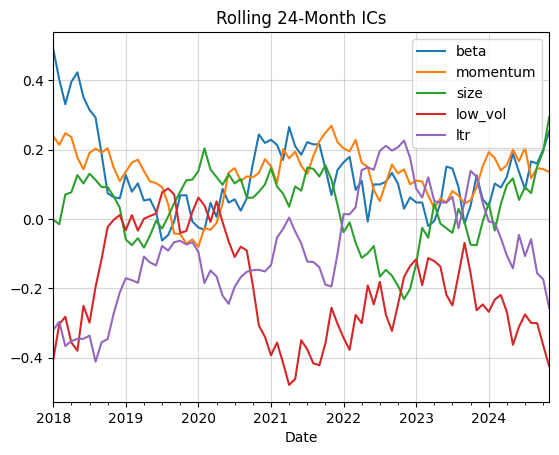

In [ ]:
# Rolling IC
fig, ax = plt.subplots()
weights_rolling.plot(ax = ax)
ax.grid(alpha = 0.5)
ax.set_title("Rolling 24-Month ICs")
plt.savefig('outputs/RollingIC.png')

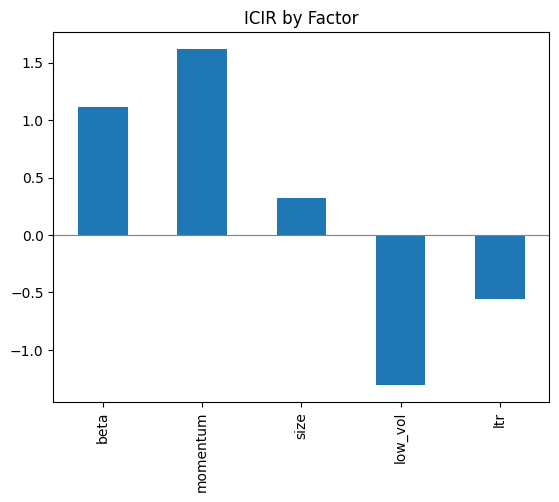

In [34]:
# ICIR by factor
fig, ax = plt.subplots()
(weights_rolling.mean() / weights_rolling.std()).plot(kind = 'bar', title = "ICIR by Factor", ax = ax)
ax.axhline(0, color='grey', linewidth=0.8)
plt.savefig('outputs/ICIR_by_Factor.png')

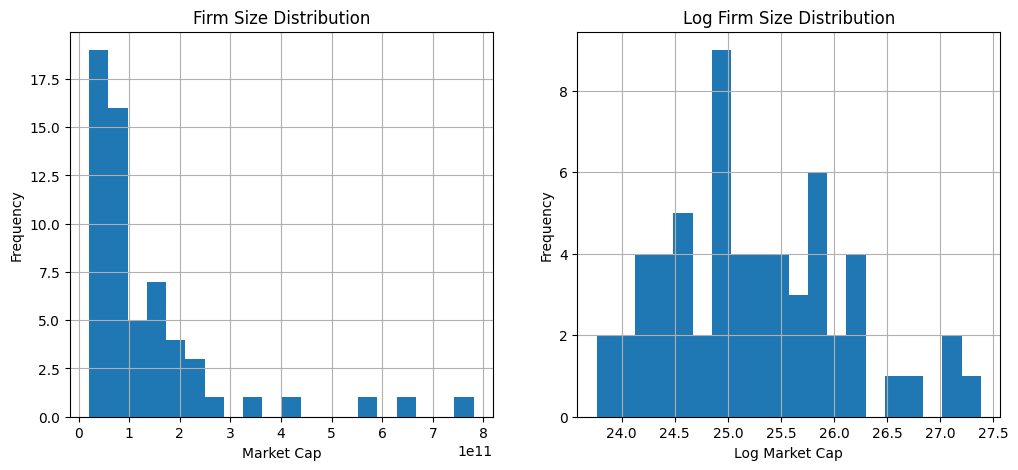

In [44]:
# Firm size distribution
fig, ax = plt.subplots(1,2, figsize=(12, 5))
market_cap.loc[t_eval[0]].hist(bins = 20, ax=ax[0])
ax[0].set_title('Firm Size Distribution')
ax[0].set_xlabel('Market Cap')
ax[0].set_ylabel('Frequency')

log_market_cap.loc[t_eval[0]].hist(bins = 20, ax=ax[1])
ax[1].set_title('Log Firm Size Distribution')
ax[1].set_xlabel('Log Market Cap')
ax[1].set_ylabel('Frequency')

plt.savefig('outputs/Firm Size Distribution.png')

Timestamp('2018-01-01 00:00:00')